# 기계학습 실습 8: CNN으로 MNIST 이미지 분류

## 학습 목표
- 28x28 MNIST 이미지를 2차원 구조 그대로 사용해 CNN을 학습한다.
- 앞 실습의 Dense Neural Network를 baseline으로 다시 학습해 CNN과 비교한다.
- test loss/accuracy와 오분류 이미지를 함께 보며 두 모델의 차이를 해석한다.

## 실습 흐름
1. MNIST 데이터 로드
2. CNN 모델 학습
3. Dense NN baseline 학습
4. 두 모델의 test accuracy/loss 비교
5. 틀린 이미지 예시 비교
6. CNN이 이미지에 유리한 이유 정리


## 1. 패키지 로드
TensorFlow/Keras로 모델을 만들고, `matplotlib`과 `pandas`로 결과를 확인한다.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models

np.random.seed(0)
tf.random.set_seed(0)

## 2. MNIST 데이터 로드
MNIST는 0부터 9까지의 손글씨 숫자 이미지 데이터이다. 각 이미지는 `28 x 28` 픽셀이고, 픽셀값은 0-255 범위의 정수이다.

In [3]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Neural network가 다루기 쉽도록 픽셀값을 0-1 범위로 정규화한다.
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print('x_train:', x_train.shape)
print('y_train:', y_train.shape)
print('x_test :', x_test.shape)
print('y_test :', y_test.shape)

x_train: (60000, 28, 28)
y_train: (60000,)
x_test : (10000, 28, 28)
y_test : (10000,)


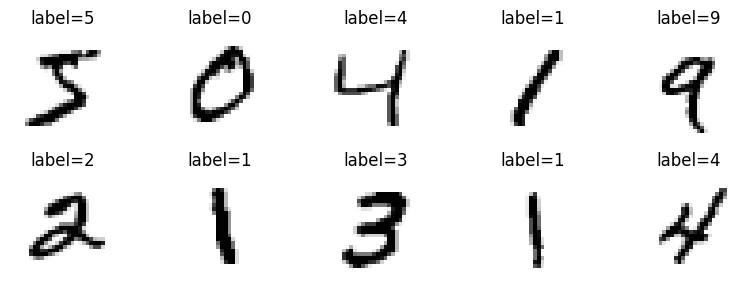

In [4]:
plt.figure(figsize=(8, 3))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray_r')
    plt.title(f'label={y_train[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## 3. CNN 입력 형태 만들기
`Conv2D` layer는 `(height, width, channels)` 형태의 이미지를 입력으로 받는다. MNIST는 흑백 이미지라 channel 수가 1이다.

<div style="display:flex; gap:24px; align-items:flex-start;">
  <img src="data:image/png;base64, ..." width="700"/>  
</div>


In [5]:
x_train_cnn = x_train[..., np.newaxis]
x_test_cnn = x_test[..., np.newaxis]

print('CNN input shape:', x_train_cnn.shape)

CNN input shape: (60000, 28, 28, 1)


## 4. CNN 모델 학습
CNN은 작은 필터를 이미지 위에서 움직이며 지역 패턴을 찾는다. 손글씨 숫자에서는 획, 곡선, 모서리 같은 패턴이 중요하다.

#### CNN

<div style="display:flex; gap:24px; align-items:flex-start;">
  <img src="data:image/png;base64, ..." width="700"/>  
</div>


In [6]:
cnn_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

E0000 00:00:1782035112.411918 2040072 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1782035112.412466 2040971 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1782035112.459663 2040072 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
EPOCHS = 5
BATCH_SIZE = 128

history_cnn = cnn_model.fit(
    x_train_cnn, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9041 - loss: 0.3221 - val_accuracy: 0.9808 - val_loss: 0.0673
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9700 - loss: 0.1008 - val_accuracy: 0.9857 - val_loss: 0.0502
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9781 - loss: 0.0737 - val_accuracy: 0.9883 - val_loss: 0.0412
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9824 - loss: 0.0590 - val_accuracy: 0.9898 - val_loss: 0.0355
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9846 - loss: 0.0498 - val_accuracy: 0.9900 - val_loss: 0.0384


In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_cnn, y_test, verbose=0)
print(f'CNN test loss    : {cnn_test_loss:.4f}')
print(f'CNN test accuracy: {cnn_test_acc:.4f}')

CNN test loss    : 0.0341
CNN test accuracy: 0.9895


## 5. Dense NN baseline 학습
앞 실습에서 사용한 방식처럼 이미지를 `28 x 28 = 784`개의 숫자로 펼친 뒤 Dense layer에 넣는다. 같은 데이터로 학습하므로 CNN과 직접 비교할 수 있다.

In [9]:
dense_model = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

dense_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

dense_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history_dense = dense_model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8704 - loss: 0.4409 - val_accuracy: 0.9617 - val_loss: 0.1463
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9404 - loss: 0.2001 - val_accuracy: 0.9680 - val_loss: 0.1083
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9545 - loss: 0.1523 - val_accuracy: 0.9748 - val_loss: 0.0895
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9624 - loss: 0.1241 - val_accuracy: 0.9767 - val_loss: 0.0794
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9679 - loss: 0.1061 - val_accuracy: 0.9792 - val_loss: 0.0774


In [11]:
dense_test_loss, dense_test_acc = dense_model.evaluate(x_test, y_test, verbose=0)
print(f'Dense NN test loss    : {dense_test_loss:.4f}')
print(f'Dense NN test accuracy: {dense_test_acc:.4f}')

Dense NN test loss    : 0.0863
Dense NN test accuracy: 0.9739


## 6. 성능 비교
두 모델은 같은 train/test split, 같은 normalization, 같은 epoch 수로 학습했다. 차이는 이미지 구조를 사용하는 방식이다.

In [12]:
results = pd.DataFrame({
    'model': ['CNN', 'Dense NN'],
    'test_loss': [cnn_test_loss, dense_test_loss],
    'test_accuracy': [cnn_test_acc, dense_test_acc]
})
results

,model,test_loss,test_accuracy
0,CNN,0.034091,0.9895
1,Dense NN,0.086311,0.9739


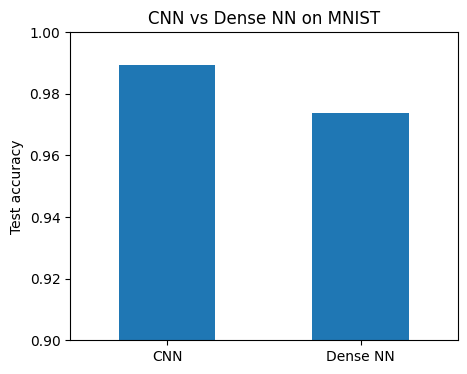

In [13]:
ax = results.plot(x='model', y='test_accuracy', kind='bar', legend=False, figsize=(5, 4), ylim=(0.9, 1.0))
ax.set_ylabel('Test accuracy')
ax.set_xlabel('')
ax.set_title('CNN vs Dense NN on MNIST')
plt.xticks(rotation=0)
plt.show()

## 7. 오분류 이미지 비교
정확도 숫자만 보면 차이가 작아 보일 수 있다. 실제로 어떤 이미지를 틀리는지 보면 모델의 한계를 더 잘 이해할 수 있다.

CNN: 105 misclassified samples out of 10000


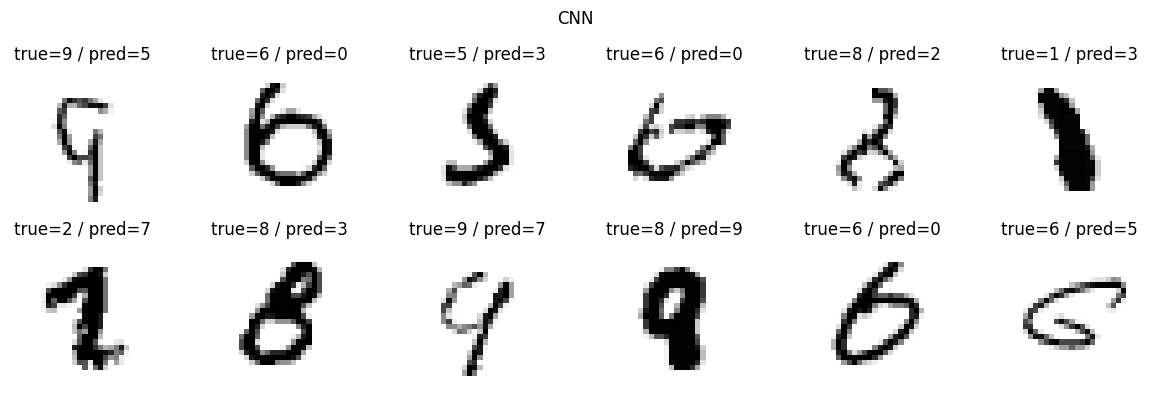

Dense NN: 261 misclassified samples out of 10000


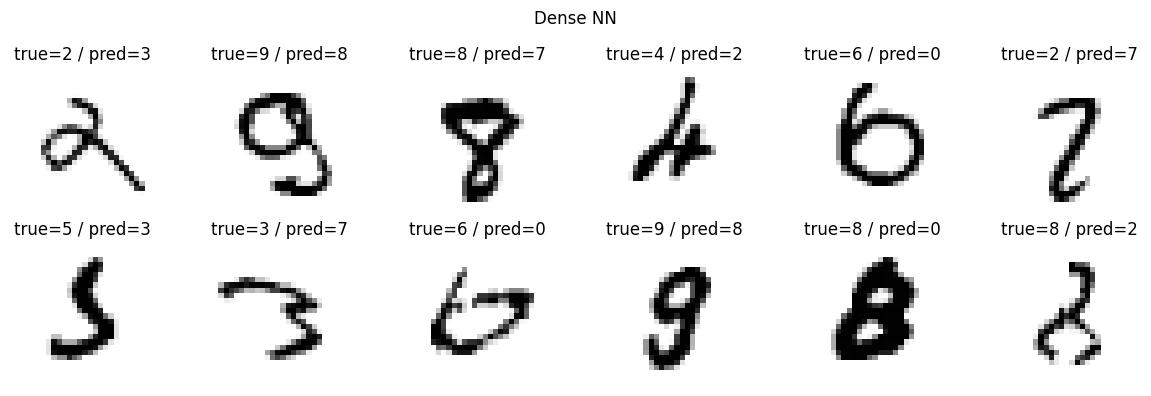

In [14]:
def plot_misclassified(model, x_eval, y_true, title, n=12):
    y_prob = model.predict(x_eval, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    wrong_idx = np.where(y_pred != y_true)[0]

    print(f'{title}: {len(wrong_idx)} misclassified samples out of {len(y_true)}')
    if len(wrong_idx) == 0:
        return

    show_idx = wrong_idx[:n]
    cols = min(6, len(show_idx))
    rows = int(np.ceil(len(show_idx) / cols))
    plt.figure(figsize=(cols * 2, rows * 2))
    for j, idx in enumerate(show_idx):
        plt.subplot(rows, cols, j + 1)
        plt.imshow(x_test[idx], cmap='gray_r')
        plt.title(f'true={y_true[idx]} / pred={y_pred[idx]}')
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_misclassified(cnn_model, x_test_cnn, y_test, 'CNN')
plot_misclassified(dense_model, x_test, y_test, 'Dense NN')

## 8. 왜 CNN이 이미지에 유리한가?
Dense NN은 이미지를 784개의 독립적인 숫자처럼 펼쳐서 본다. 이 방식도 MNIST처럼 단순한 데이터에서는 꽤 잘 작동하지만, 픽셀의 이웃 관계와 2차원 위치 정보를 직접 활용하지는 못한다.

CNN은 작은 필터를 통해 주변 픽셀의 패턴을 먼저 찾고, pooling으로 위치가 조금 달라져도 비슷한 패턴으로 인식한다. 그래서 이미지처럼 공간 구조가 중요한 데이터에서는 Dense NN보다 자연스러운 모델 구조가 된다.

정리하면, Dense NN은 “이미지를 긴 표 형태의 feature vector로 보는 방법”이고, CNN은 “이미지를 이미지답게 보는 방법”이다.

## 실습 과제
1. CNN의 filter 수를 16, 32, 64로 바꾸어 성능 변화를 확인하라.
2. Dense NN의 hidden layer neuron 수를 바꾸어 CNN과 비교하라.
3. epoch 수를 늘렸을 때 두 모델 중 어느 쪽이 더 빨리 overfitting되는지 확인하라.